In [1]:
# ── CELL 0: INSTALL & IMPORTS ──────────────────────────
import subprocess, sys
for pkg in ['prophet', 'lightgbm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import mstats
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from numpy.polynomial import polynomial as P

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
# ── CELL 1: LOAD DATA & BASIC CHECKS ──────────────────
df_polis = pd.read_csv('Data_Polis.csv')
df_klaim = pd.read_csv('Data_Klaim.csv')

# Strip whitespace semua kolom string
df_polis.columns = df_polis.columns.str.strip()
df_klaim.columns = df_klaim.columns.str.strip()

for col in df_polis.select_dtypes('object').columns:
    df_polis[col] = df_polis[col].str.strip()
for col in df_klaim.select_dtypes('object').columns:
    df_klaim[col] = df_klaim[col].str.strip()

# Parse tanggal polis
df_polis['Tanggal Lahir']          = pd.to_datetime(df_polis['Tanggal Lahir'], format='%Y%m%d')
df_polis['Tanggal Efektif Polis']  = pd.to_datetime(df_polis['Tanggal Efektif Polis'], format='%Y%m%d')

# Parse tanggal klaim
df_klaim['Tanggal Pembayaran Klaim']  = pd.to_datetime(df_klaim['Tanggal Pembayaran Klaim'], errors='coerce')
df_klaim['Tanggal Pasien Masuk RS']   = pd.to_datetime(df_klaim['Tanggal Pasien Masuk RS'],  errors='coerce')
df_klaim['Tanggal Pasien Keluar RS']  = pd.to_datetime(df_klaim['Tanggal Pasien Keluar RS'], errors='coerce')

# ── MISSING VALUES ─────────────────────────────────────
print("=" * 50)
print("MISSING VALUES — DATA POLIS")
print("=" * 50)
mv_polis = df_polis.isnull().sum()
print(mv_polis[mv_polis > 0] if mv_polis.sum() > 0 else "✅ Tidak ada missing value")

print("\n" + "=" * 50)
print("MISSING VALUES — DATA KLAIM")
print("=" * 50)
mv_klaim = df_klaim.isnull().sum()
print(mv_klaim[mv_klaim > 0] if mv_klaim.sum() > 0 else "✅ Tidak ada missing value")

# ── FILTER PAID & DEDUPLIKASI ──────────────────────────
df_klaim = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()
before   = len(df_klaim)
df_klaim = df_klaim.drop_duplicates(subset='Claim ID')
print(f"\n✅ Filter PAID: {len(df_klaim)} rows")
print(f"✅ Duplikat dihapus: {before - len(df_klaim)} rows")

# ── WINSORIZE 1%-99% DI LEVEL INDIVIDUAL KLAIM ────────
# Dilakukan sebelum agregasi — lebih tepat untuk data klaim yang skewed
low_p  = np.percentile(df_klaim['Nominal Klaim Yang Disetujui'], 1)
high_p = np.percentile(df_klaim['Nominal Klaim Yang Disetujui'], 99)
df_klaim['Nominal Klaim Yang Disetujui'] = df_klaim['Nominal Klaim Yang Disetujui'].clip(low_p, high_p)

print(f"\n✅ Winsorize 1%-99% selesai")
print(f"   Lower bound : Rp {low_p:,.0f}")
print(f"   Upper bound : Rp {high_p:,.0f}")

# ── PERIODE KLAIM ──────────────────────────────────────
df_klaim['Periode_Klaim'] = (
    df_klaim['Tanggal Pasien Masuk RS']
    .dt.to_period('M')
    .dt.to_timestamp()
)

print(f"\n✅ Cell 1 selesai")
print(f"   Polis : {df_polis.shape}")
print(f"   Klaim : {df_klaim.shape}")

MISSING VALUES — DATA POLIS
✅ Tidak ada missing value

MISSING VALUES — DATA KLAIM
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64

✅ Filter PAID: 4627 rows
✅ Duplikat dihapus: 0 rows

✅ Winsorize 1%-99% selesai
   Lower bound : Rp 187,242
   Upper bound : Rp 633,686,130

✅ Cell 1 selesai
   Polis : (4096, 6)
   Klaim : (4627, 14)


In [3]:
# ── CELL 3: AGREGASI BULANAN, EXPOSURE & FEATURE ENGINEERING ──

# ── AGREGASI BULANAN ───────────────────────────────────
df_monthly = df_klaim.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum'),
    Claim_Severity=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()

df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

print("=" * 50)
print("DATA BULANAN")
print("=" * 50)
display(df_monthly)
print(f"\nRentang  : {df_monthly['Periode_Klaim'].min()} → {df_monthly['Periode_Klaim'].max()}")
print(f"Total    : {len(df_monthly)} bulan")

# ── EXPOSURE PER BULAN ─────────────────────────────────
# Hitung jumlah polis aktif per bulan sebagai exposure
exposure_list = []
for period in df_monthly['Periode_Klaim']:
    period_end = period + pd.offsets.MonthEnd(0)
    n_active   = df_polis[
        df_polis['Tanggal Efektif Polis'] <= period_end
    ].shape[0]
    exposure_list.append({'Periode_Klaim': period, 'Exposure': n_active})

df_exposure = pd.DataFrame(exposure_list)
df_monthly  = df_monthly.merge(df_exposure, on='Periode_Klaim', how='left')

# Claim Rate = Frequency / Exposure (normalisasi portfolio)
df_monthly['Claim_Rate'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Exposure']
)

print("\n" + "=" * 50)
print("EXPOSURE PER BULAN")
print("=" * 50)
display(df_monthly[['Periode_Klaim', 'Exposure', 'Claim_Rate']])

# ── EXPOSURE FORECAST: TREN LINEAR ────────────────────
# Fit tren linear ke exposure historis untuk proyeksi 17 bulan
time_idx      = np.arange(len(df_monthly))
exp_values    = df_monthly['Exposure'].values
coeffs        = np.polyfit(time_idx, exp_values, 1)  # slope, intercept
exposure_poly = np.poly1d(coeffs)

future_idx_start = len(df_monthly)
future_exposure  = [
    max(int(exposure_poly(future_idx_start + i)), df_monthly['Exposure'].max())
    for i in range(17)
]

print(f"\n✅ Tren linear exposure: slope = {coeffs[0]:.2f} polis/bulan")
print(f"   Exposure historis terakhir : {df_monthly['Exposure'].iloc[-1]}")
print(f"   Exposure forecast bulan 1  : {future_exposure[0]}")
print(f"   Exposure forecast bulan 17 : {future_exposure[16]}")

# ── CALENDAR FEATURES ──────────────────────────────────
df_monthly['Time_Index'] = np.arange(len(df_monthly))
df_monthly['Month']      = df_monthly['Periode_Klaim'].dt.month
df_monthly['Quarter']    = df_monthly['Periode_Klaim'].dt.quarter

# Cyclical encoding bulan
df_monthly['Month_Sin'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Month_Cos'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# Cyclical encoding quarter
df_monthly['Quarter_Sin'] = np.sin(2 * np.pi * df_monthly['Quarter'] / 4)
df_monthly['Quarter_Cos'] = np.cos(2 * np.pi * df_monthly['Quarter'] / 4)

# ── LAG FEATURES (tanpa Lag_12 & YoY) ────────────────
# Frequency
df_monthly['Freq_Lag_1'] = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_2'] = df_monthly['Claim_Frequency'].shift(2)
df_monthly['Freq_Lag_3'] = df_monthly['Claim_Frequency'].shift(3)

# Severity
df_monthly['Sev_Lag_1']  = df_monthly['Claim_Severity'].shift(1)
df_monthly['Sev_Lag_2']  = df_monthly['Claim_Severity'].shift(2)
df_monthly['Sev_Lag_3']  = df_monthly['Claim_Severity'].shift(3)

# Total
df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)
df_monthly['Total_Lag_2'] = df_monthly['Total_Claim'].shift(2)

# ── ROLLING FEATURES ──────────────────────────────────
# Rolling mean window 3
df_monthly['Freq_Rolling_3']  = df_monthly['Claim_Frequency'].shift(1).rolling(3).mean()
df_monthly['Sev_Rolling_3']   = df_monthly['Claim_Severity'].shift(1).rolling(3).mean()
df_monthly['Total_Rolling_3'] = df_monthly['Total_Claim'].shift(1).rolling(3).mean()

# Rolling mean window 6
df_monthly['Freq_Rolling_6']  = df_monthly['Claim_Frequency'].shift(1).rolling(6).mean()
df_monthly['Sev_Rolling_6']   = df_monthly['Claim_Severity'].shift(1).rolling(6).mean()
df_monthly['Total_Rolling_6'] = df_monthly['Total_Claim'].shift(1).rolling(6).mean()

# Rolling std window 3 (volatilitas)
df_monthly['Freq_Std_3'] = df_monthly['Claim_Frequency'].shift(1).rolling(3).std()
df_monthly['Sev_Std_3']  = df_monthly['Claim_Severity'].shift(1).rolling(3).std()

# Growth rate MoM
df_monthly['Freq_Growth'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Freq_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

df_monthly['Sev_Growth'] = (
    df_monthly['Claim_Severity'] / df_monthly['Sev_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

# ── SEASONAL NAIVE PRECOMPUTE ──────────────────────────
# Hitung rata-rata historis per bulan untuk Seasonal Naive
# Untuk bulan dengan hanya 1 observasi: 50% aktual + 50% rolling mean 3 bulan sekitar
seasonal_naive = {}
for month in range(1, 13):
    month_data = df_monthly[df_monthly['Month'] == month]
    surrounding = df_monthly[
        df_monthly['Month'].isin([(month - 1) % 12 + 1, month, (month + 1) % 12 + 1])
    ]
    for target in ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']:
        if len(month_data) >= 2:
            val = month_data[target].mean()
        else:
            actual_val      = month_data[target].mean() if len(month_data) > 0 else surrounding[target].mean()
            surrounding_val = surrounding[target].mean()
            val             = 0.5 * actual_val + 0.5 * surrounding_val
        seasonal_naive[(month, target)] = val

print("\n✅ Seasonal Naive per bulan:")
for month in range(1, 13):
    print(f"   Bulan {month:02d} | "
          f"Freq: {seasonal_naive[(month, 'Claim_Frequency')]:.1f} | "
          f"Sev: {seasonal_naive[(month, 'Claim_Severity')]/1e6:.2f}M | "
          f"Total: {seasonal_naive[(month, 'Total_Claim')]/1e9:.3f}B")

# ── FEATURE SETS PER TARGET ───────────────────────────
FEATURES_FREQ = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_3',
    'Freq_Rolling_3', 'Freq_Rolling_6', 'Freq_Std_3',
    'Total_Lag_1', 'Exposure',
]

FEATURES_SEV = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Sev_Lag_1', 'Sev_Lag_2', 'Sev_Lag_3',
    'Sev_Rolling_3', 'Sev_Rolling_6', 'Sev_Std_3',
    'Freq_Lag_1', 'Exposure',
]

FEATURES_TOTAL = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Total_Lag_1', 'Total_Lag_2',
    'Total_Rolling_3', 'Total_Rolling_6',
    'Freq_Lag_1', 'Sev_Lag_1', 'Exposure',
]

print(f"\n✅ Feature sets:")
print(f"   Frequency : {len(FEATURES_FREQ)} fitur")
print(f"   Severity  : {len(FEATURES_SEV)} fitur")
print(f"   Total     : {len(FEATURES_TOTAL)} fitur")

print("\n✅ Cell 3 selesai")

DATA BULANAN


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity
0,2024-01-01,302,1.895190e+10,6.275465e+07
1,2024-02-01,208,1.264589e+10,6.079755e+07
2,2024-03-01,278,1.414070e+10,5.086583e+07
3,2024-04-01,239,1.120960e+10,4.690211e+07
4,2024-05-01,263,1.123643e+10,4.272406e+07
5,2024-06-01,225,1.212653e+10,5.389569e+07
6,2024-07-01,257,1.374646e+10,5.348818e+07
7,2024-08-01,228,1.196234e+10,5.246642e+07
8,2024-09-01,208,1.108477e+10,5.329216e+07
9,2024-10-01,274,1.268139e+10,4.628243e+07



Rentang  : 2024-01-01 00:00:00 → 2025-07-01 00:00:00
Total    : 19 bulan

EXPOSURE PER BULAN


,Periode_Klaim,Exposure,Claim_Rate
0,2024-01-01,4096,0.073730
1,2024-02-01,4096,0.050781
2,2024-03-01,4096,0.067871
3,2024-04-01,4096,0.058350
4,2024-05-01,4096,0.064209
5,2024-06-01,4096,0.054932
6,2024-07-01,4096,0.062744
7,2024-08-01,4096,0.055664
8,2024-09-01,4096,0.050781
9,2024-10-01,4096,0.066895



✅ Tren linear exposure: slope = 0.00 polis/bulan
   Exposure historis terakhir : 4096
   Exposure forecast bulan 1  : 4096
   Exposure forecast bulan 17 : 4096

✅ Seasonal Naive per bulan:
   Bulan 01 | Freq: 259.0 | Sev: 53.35M | Total: 14.222B
   Bulan 02 | Freq: 227.0 | Sev: 59.56M | Total: 13.496B
   Bulan 03 | Freq: 254.0 | Sev: 51.96M | Total: 13.171B
   Bulan 04 | Freq: 223.5 | Sev: 48.85M | Total: 10.888B
   Bulan 05 | Freq: 251.0 | Sev: 46.74M | Total: 11.684B
   Bulan 06 | Freq: 229.5 | Sev: 52.74M | Total: 12.098B
   Bulan 07 | Freq: 260.5 | Sev: 50.78M | Total: 13.218B
   Bulan 08 | Freq: 239.5 | Sev: 50.92M | Total: 12.142B
   Bulan 09 | Freq: 223.5 | Sev: 52.43M | Total: 11.679B
   Bulan 10 | Freq: 265.0 | Sev: 45.77M | Total: 12.144B
   Bulan 11 | Freq: 266.3 | Sev: 51.02M | Total: 13.715B
   Bulan 12 | Freq: 234.3 | Sev: 49.35M | Total: 11.520B

✅ Feature sets:
   Frequency : 13 fitur
   Severity  : 13 fitur
   Total     : 12 fitur

✅ Cell 3 selesai


In [4]:
# ── CELL 4: WALK-FORWARD VALIDATION ───────────────────

# ── HELPER FUNCTIONS ───────────────────────────────────
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def run_prophet(train_df, target_col, periods=1):
    """
    Prophet dengan quarterly seasonality.
    Yearly seasonality dimatikan — tidak reliable dengan < 24 bulan data.
    """
    prophet_df = train_df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.01,   # conservative — hindari overfitting trend
        seasonality_prior_scale=1.0,
    )
    # Quarterly seasonality lebih reliable untuk 19 bulan data
    model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    model.fit(prophet_df, algorithm='Newton')

    future   = model.make_future_dataframe(periods=periods, freq='MS')
    forecast = model.predict(future)
    pred     = forecast['yhat'].iloc[-periods:].values
    return np.clip(pred, 0, None)

def run_lgbm(train_df, val_df, features, target_col):
    """LightGBM dengan regularisasi untuk data kecil."""
    # Drop NaN di features
    train_clean = train_df.dropna(subset=features)
    val_clean   = val_df.dropna(subset=features)

    if len(train_clean) < 5 or len(val_clean) == 0:
        return np.array([np.nan])

    X_train = train_clean[features]
    y_train = train_clean[target_col]
    X_val   = val_clean[features]

    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return np.clip(pred, 0, None)

def get_seasonal_naive(month, target_col):
    """Ambil seasonal naive value untuk bulan dan target tertentu."""
    return seasonal_naive.get((month, target_col), 0)

# ── WALK-FORWARD SPLITS ────────────────────────────────
# Min train 14 bulan → fold pertama val di bulan ke-15
MIN_TRAIN = 14

splits = []
n      = len(df_monthly)
for val_idx in range(MIN_TRAIN, n):
    train = df_monthly.iloc[:val_idx].copy()
    val   = df_monthly.iloc[val_idx:val_idx + 1].copy()
    splits.append((train, val))

print("=" * 50)
print("WALK-FORWARD SPLITS")
print("=" * 50)
print(f"Jumlah fold: {len(splits)}")
for i, (tr, vl) in enumerate(splits):
    print(f"  Fold {i+1} | Train: "
          f"{tr['Periode_Klaim'].min().strftime('%Y-%m')} → "
          f"{tr['Periode_Klaim'].max().strftime('%Y-%m')} "
          f"({len(tr)} bln) | Val: "
          f"{vl['Periode_Klaim'].iloc[0].strftime('%Y-%m')}")

# ── VALIDASI PER MODEL PER TARGET ─────────────────────
targets = {
    'Claim_Frequency' : FEATURES_FREQ,
    'Claim_Severity'  : FEATURES_SEV,
    'Total_Claim'     : FEATURES_TOTAL,
}

val_results = {
    target: {
        'prophet_preds' : [],
        'lgbm_preds'    : [],
        'naive_preds'   : [],
        'actuals'       : [],
    }
    for target in targets
}

print("\n" + "=" * 50)
print("RUNNING WALK-FORWARD VALIDATION")
print("=" * 50)

for i, (train, val) in enumerate(splits):
    val_month  = val['Periode_Klaim'].iloc[0].month
    val_period = val['Periode_Klaim'].iloc[0].strftime('%Y-%m')

    for target_col, features in targets.items():
        actual = val[target_col].iloc[0]
        val_results[target_col]['actuals'].append(actual)

        # Prophet
        try:
            p_prophet = run_prophet(train, target_col, periods=1)[0]
        except Exception:
            p_prophet = train[target_col].mean()
        val_results[target_col]['prophet_preds'].append(p_prophet)

        # LightGBM
        p_lgbm = run_lgbm(train, val, features, target_col)
        p_lgbm = p_lgbm[0] if len(p_lgbm) > 0 and not np.isnan(p_lgbm[0]) \
                 else train[target_col].mean()
        val_results[target_col]['lgbm_preds'].append(p_lgbm)

        # Seasonal Naive
        p_naive = get_seasonal_naive(val_month, target_col)
        val_results[target_col]['naive_preds'].append(p_naive)

    print(f"  Fold {i+1} selesai | Val: {val_period}")

# ── HITUNG MAPE PER MODEL ──────────────────────────────
print("\n" + "=" * 60)
print("VALIDATION MAPE PER MODEL")
print("=" * 60)
print(f"{'Target':<20} {'Prophet':>10} {'LightGBM':>10} {'Naive':>10}")
print("-" * 60)

mape_scores = {}
for target_col in targets:
    actuals = val_results[target_col]['actuals']
    m_p     = safe_mape(actuals, val_results[target_col]['prophet_preds'])
    m_l     = safe_mape(actuals, val_results[target_col]['lgbm_preds'])
    m_n     = safe_mape(actuals, val_results[target_col]['naive_preds'])
    mape_scores[target_col] = {'prophet': m_p, 'lgbm': m_l, 'naive': m_n}
    print(f"  {target_col:<18} {m_p:>9.2f}% {m_l:>9.2f}% {m_n:>9.2f}%")

# ── HITUNG BOBOT INVERSE MAPE ─────────────────────────
# Bobot = 1/MAPE dinormalisasi, dihitung independen per model
# Bukan dioptimasi di validation set → lebih robust
print("\n" + "=" * 60)
print("BOBOT ENSEMBLE — INVERSE MAPE (INDEPENDEN)")
print("=" * 60)
print(f"{'Target':<20} {'w_Prophet':>10} {'w_LightGBM':>10} {'w_Naive':>10}")
print("-" * 60)

base_weights = {}
for target_col in targets:
    scores = mape_scores[target_col]
    # Hindari division by zero
    eps   = 1e-6
    inv_p = 1 / (scores['prophet'] + eps)
    inv_l = 1 / (scores['lgbm']    + eps)
    inv_n = 1 / (scores['naive']   + eps)
    total = inv_p + inv_l + inv_n

    w_p = round(inv_p / total, 3)
    w_l = round(inv_l / total, 3)
    w_n = round(inv_n / total, 3)
    # Normalisasi agar tepat = 1
    w_n = round(1 - w_p - w_l, 3)

    base_weights[target_col] = {'prophet': w_p, 'lgbm': w_l, 'naive': w_n}
    print(f"  {target_col:<18} {w_p:>10.3f} {w_l:>10.3f} {w_n:>10.3f}")

# ── ENSEMBLE MAPE DI VALIDASI ──────────────────────────
print("\n" + "=" * 60)
print("ENSEMBLE MAPE DI VALIDASI (BASE WEIGHTS)")
print("=" * 60)

ensemble_val_mapes = {}
for target_col in targets:
    actuals = np.array(val_results[target_col]['actuals'])
    p_preds = np.array(val_results[target_col]['prophet_preds'])
    l_preds = np.array(val_results[target_col]['lgbm_preds'])
    n_preds = np.array(val_results[target_col]['naive_preds'])

    w = base_weights[target_col]
    ensemble_preds = (
        w['prophet'] * p_preds +
        w['lgbm']    * l_preds +
        w['naive']   * n_preds
    )
    m_ens = safe_mape(actuals, ensemble_preds)
    ensemble_val_mapes[target_col] = m_ens
    print(f"  {target_col:<20}: {m_ens:.2f}%")

avg_ens_mape = np.mean(list(ensemble_val_mapes.values()))
print(f"\n  Average Ensemble MAPE : {avg_ens_mape:.2f}%")

print("\n✅ Cell 4 selesai")

WALK-FORWARD SPLITS
Jumlah fold: 5
  Fold 1 | Train: 2024-01 → 2025-02 (14 bln) | Val: 2025-03
  Fold 2 | Train: 2024-01 → 2025-03 (15 bln) | Val: 2025-04
  Fold 3 | Train: 2024-01 → 2025-04 (16 bln) | Val: 2025-05
  Fold 4 | Train: 2024-01 → 2025-05 (17 bln) | Val: 2025-06
  Fold 5 | Train: 2024-01 → 2025-06 (18 bln) | Val: 2025-07

RUNNING WALK-FORWARD VALIDATION


11:47:36 - cmdstanpy - INFO - Chain [1] start processing
11:47:37 - cmdstanpy - INFO - Chain [1] done processing
11:47:40 - cmdstanpy - INFO - Chain [1] start processing
11:47:41 - cmdstanpy - INFO - Chain [1] done processing
11:47:41 - cmdstanpy - INFO - Chain [1] start processing
11:47:41 - cmdstanpy - INFO - Chain [1] done processing


  Fold 1 selesai | Val: 2025-03


11:47:41 - cmdstanpy - INFO - Chain [1] start processing
11:47:42 - cmdstanpy - INFO - Chain [1] done processing
11:47:42 - cmdstanpy - INFO - Chain [1] start processing
11:47:42 - cmdstanpy - INFO - Chain [1] done processing
11:47:42 - cmdstanpy - INFO - Chain [1] start processing
11:47:43 - cmdstanpy - INFO - Chain [1] done processing


  Fold 2 selesai | Val: 2025-04


...

  Fold 3 selesai | Val: 2025-05


11:47:45 - cmdstanpy - INFO - Chain [1] start processing
11:47:45 - cmdstanpy - INFO - Chain [1] done processing
11:47:45 - cmdstanpy - INFO - Chain [1] start processing
11:47:45 - cmdstanpy - INFO - Chain [1] done processing
11:47:46 - cmdstanpy - INFO - Chain [1] start processing
11:47:46 - cmdstanpy - INFO - Chain [1] done processing


  Fold 4 selesai | Val: 2025-06


11:47:46 - cmdstanpy - INFO - Chain [1] start processing
11:47:46 - cmdstanpy - INFO - Chain [1] done processing
11:47:47 - cmdstanpy - INFO - Chain [1] start processing
11:47:47 - cmdstanpy - INFO - Chain [1] done processing
11:47:47 - cmdstanpy - INFO - Chain [1] start processing
11:47:47 - cmdstanpy - INFO - Chain [1] done processing


  Fold 5 selesai | Val: 2025-07

VALIDATION MAPE PER MODEL
Target                  Prophet   LightGBM      Naive
------------------------------------------------------------
  Claim_Frequency        14.36%      7.00%      5.23%
  Claim_Severity         16.15%      7.25%      4.34%
  Total_Claim            16.00%      7.84%      3.82%

BOBOT ENSEMBLE — INVERSE MAPE (INDEPENDEN)
Target                w_Prophet w_LightGBM    w_Naive
------------------------------------------------------------
  Claim_Frequency         0.173      0.354      0.473
  Claim_Severity          0.144      0.320      0.536
  Total_Claim             0.138      0.282      0.580

ENSEMBLE MAPE DI VALIDASI (BASE WEIGHTS)
  Claim_Frequency     : 6.76%
  Claim_Severity      : 4.89%
  Total_Claim         : 2.72%

  Average Ensemble MAPE : 4.79%

✅ Cell 4 selesai


TRAINING PROPHET — Full Data


11:47:48 - cmdstanpy - INFO - Chain [1] start processing
11:47:48 - cmdstanpy - INFO - Chain [1] done processing
11:47:48 - cmdstanpy - INFO - Chain [1] start processing


  ✅ Prophet Frequency selesai


11:47:48 - cmdstanpy - INFO - Chain [1] done processing
11:47:48 - cmdstanpy - INFO - Chain [1] start processing


  ✅ Prophet Severity selesai


11:47:49 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Prophet Total selesai

TRAINING LIGHTGBM — Full Data
  ✅ LightGBM Frequency selesai
  ✅ LightGBM Severity selesai
  ✅ LightGBM Total selesai

IN-SAMPLE MAPE LIGHTGBM (referensi, bukan evaluasi utama)
  Frequency  : 0.43%
  Severity   : 0.79%
  Total Claim: 0.37%
  ⚠️  In-sample MAPE selalu lebih rendah dari walk-forward — 
     gunakan Cell 4 sebagai acuan evaluasi utama

FEATURE IMPORTANCE — LightGBM


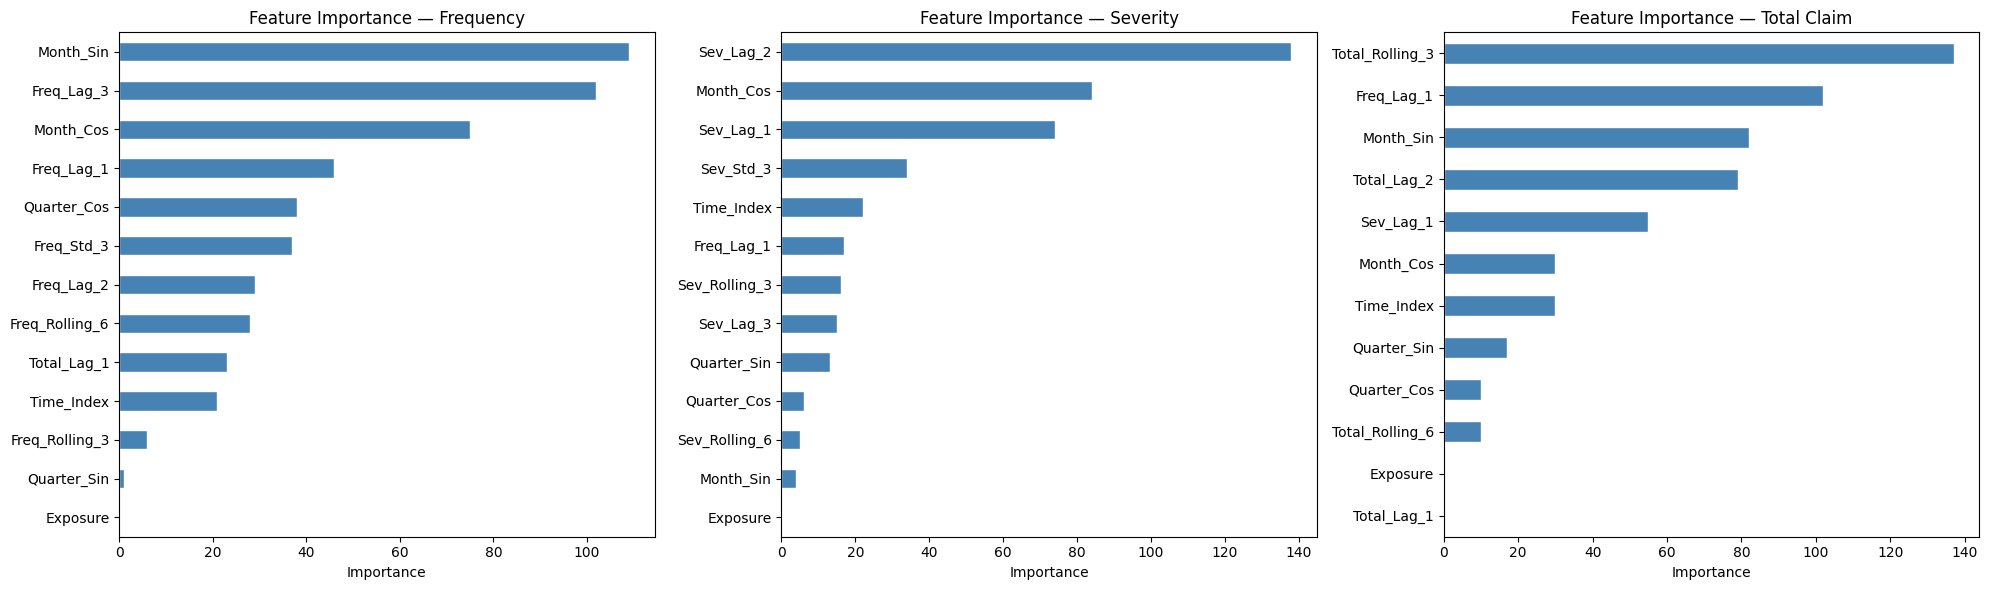


RINGKASAN BOBOT ENSEMBLE (dari Cell 4)
Target                  Prophet   LightGBM      Naive
------------------------------------------------------------
  Claim_Frequency         0.173      0.354      0.473
  Claim_Severity          0.144      0.320      0.536
  Total_Claim             0.138      0.282      0.580

✅ Cell 5 selesai — semua model siap untuk forecasting


In [5]:
# ── CELL 5: TRAINING FINAL MODELS — FULL DATA ─────────

# ── PROPHET FINAL ──────────────────────────────────────
def fit_prophet_full(df, target_col):
    prophet_df = df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.01,
        seasonality_prior_scale=1.0,
    )
    model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    model.fit(prophet_df, algorithm='Newton')
    return model

print("=" * 50)
print("TRAINING PROPHET — Full Data")
print("=" * 50)

prophet_freq  = fit_prophet_full(df_monthly, 'Claim_Frequency')
print("  ✅ Prophet Frequency selesai")

prophet_sev   = fit_prophet_full(df_monthly, 'Claim_Severity')
print("  ✅ Prophet Severity selesai")

prophet_total = fit_prophet_full(df_monthly, 'Total_Claim')
print("  ✅ Prophet Total selesai")

# ── LIGHTGBM FINAL ─────────────────────────────────────
def fit_lgbm_full(df, features, target_col):
    df_clean = df.dropna(subset=features)
    X = df_clean[features]
    y = df_clean[target_col]
    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X, y)
    return model

print("\n" + "=" * 50)
print("TRAINING LIGHTGBM — Full Data")
print("=" * 50)

lgbm_freq  = fit_lgbm_full(df_monthly, FEATURES_FREQ,  'Claim_Frequency')
print("  ✅ LightGBM Frequency selesai")

lgbm_sev   = fit_lgbm_full(df_monthly, FEATURES_SEV,   'Claim_Severity')
print("  ✅ LightGBM Severity selesai")

lgbm_total = fit_lgbm_full(df_monthly, FEATURES_TOTAL, 'Total_Claim')
print("  ✅ LightGBM Total selesai")

# ── IN-SAMPLE MAPE (INFORMASI SAJA) ───────────────────
print("\n" + "=" * 50)
print("IN-SAMPLE MAPE LIGHTGBM (referensi, bukan evaluasi utama)")
print("=" * 50)

df_clean_freq  = df_monthly.dropna(subset=FEATURES_FREQ)
df_clean_sev   = df_monthly.dropna(subset=FEATURES_SEV)
df_clean_total = df_monthly.dropna(subset=FEATURES_TOTAL)

insample_freq  = safe_mape(
    df_clean_freq['Claim_Frequency'],
    lgbm_freq.predict(df_clean_freq[FEATURES_FREQ])
)
insample_sev   = safe_mape(
    df_clean_sev['Claim_Severity'],
    lgbm_sev.predict(df_clean_sev[FEATURES_SEV])
)
insample_total = safe_mape(
    df_clean_total['Total_Claim'],
    lgbm_total.predict(df_clean_total[FEATURES_TOTAL])
)

print(f"  Frequency  : {insample_freq:.2f}%")
print(f"  Severity   : {insample_sev:.2f}%")
print(f"  Total Claim: {insample_total:.2f}%")
print(f"  ⚠️  In-sample MAPE selalu lebih rendah dari walk-forward — ")
print(f"     gunakan Cell 4 sebagai acuan evaluasi utama")

# ── FEATURE IMPORTANCE ─────────────────────────────────
print("\n" + "=" * 50)
print("FEATURE IMPORTANCE — LightGBM")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (model, features, label) in zip(axes, [
    (lgbm_freq,  FEATURES_FREQ,  'Frequency'),
    (lgbm_sev,   FEATURES_SEV,   'Severity'),
    (lgbm_total, FEATURES_TOTAL, 'Total Claim'),
]):
    imp = pd.Series(model.feature_importances_, index=features)
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance — {label}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# ── SUMMARY BOBOT YANG AKAN DIPAKAI ───────────────────
print("\n" + "=" * 60)
print("RINGKASAN BOBOT ENSEMBLE (dari Cell 4)")
print("=" * 60)
print(f"{'Target':<20} {'Prophet':>10} {'LightGBM':>10} {'Naive':>10}")
print("-" * 60)
for target_col in targets:
    w = base_weights[target_col]
    print(f"  {target_col:<18} {w['prophet']:>10.3f} "
          f"{w['lgbm']:>10.3f} {w['naive']:>10.3f}")

print("\n✅ Cell 5 selesai — semua model siap untuk forecasting")

FORECAST — Agustus 2025 s/d Desember 2026
Periode          Freq    Sev(Jt)   Total(M)     wP     wL     wN   Zona
----------------------------------------------------------------------
  2025-08       235.1      51.23     11.549  0.295  0.605  0.100      ML
  2025-09       223.3      48.74     10.426  0.295  0.605  0.100      ML
  2025-10       248.4      48.56     12.951  0.295  0.605  0.100      ML
  2025-11       247.1      46.95     12.765  0.295  0.605  0.100      ML
  2025-12       221.6      45.89     10.201  0.295  0.605  0.100      ML
  2026-01       227.3      45.67     10.783  0.274  0.560  0.167 Balance
  2026-02       224.5      53.48     13.428  0.252  0.515  0.233 Balance
  2026-03       231.6      48.39     12.917  0.230  0.470  0.300 Balance
  2026-04       220.9      50.87     10.790  0.208  0.425  0.367 Balance
  2026-05       237.6      47.33     10.815  0.186  0.381  0.433 Balance
  2026-06       228.3      51.51     11.712  0.164  0.336  0.500 Balance
  2026-07   

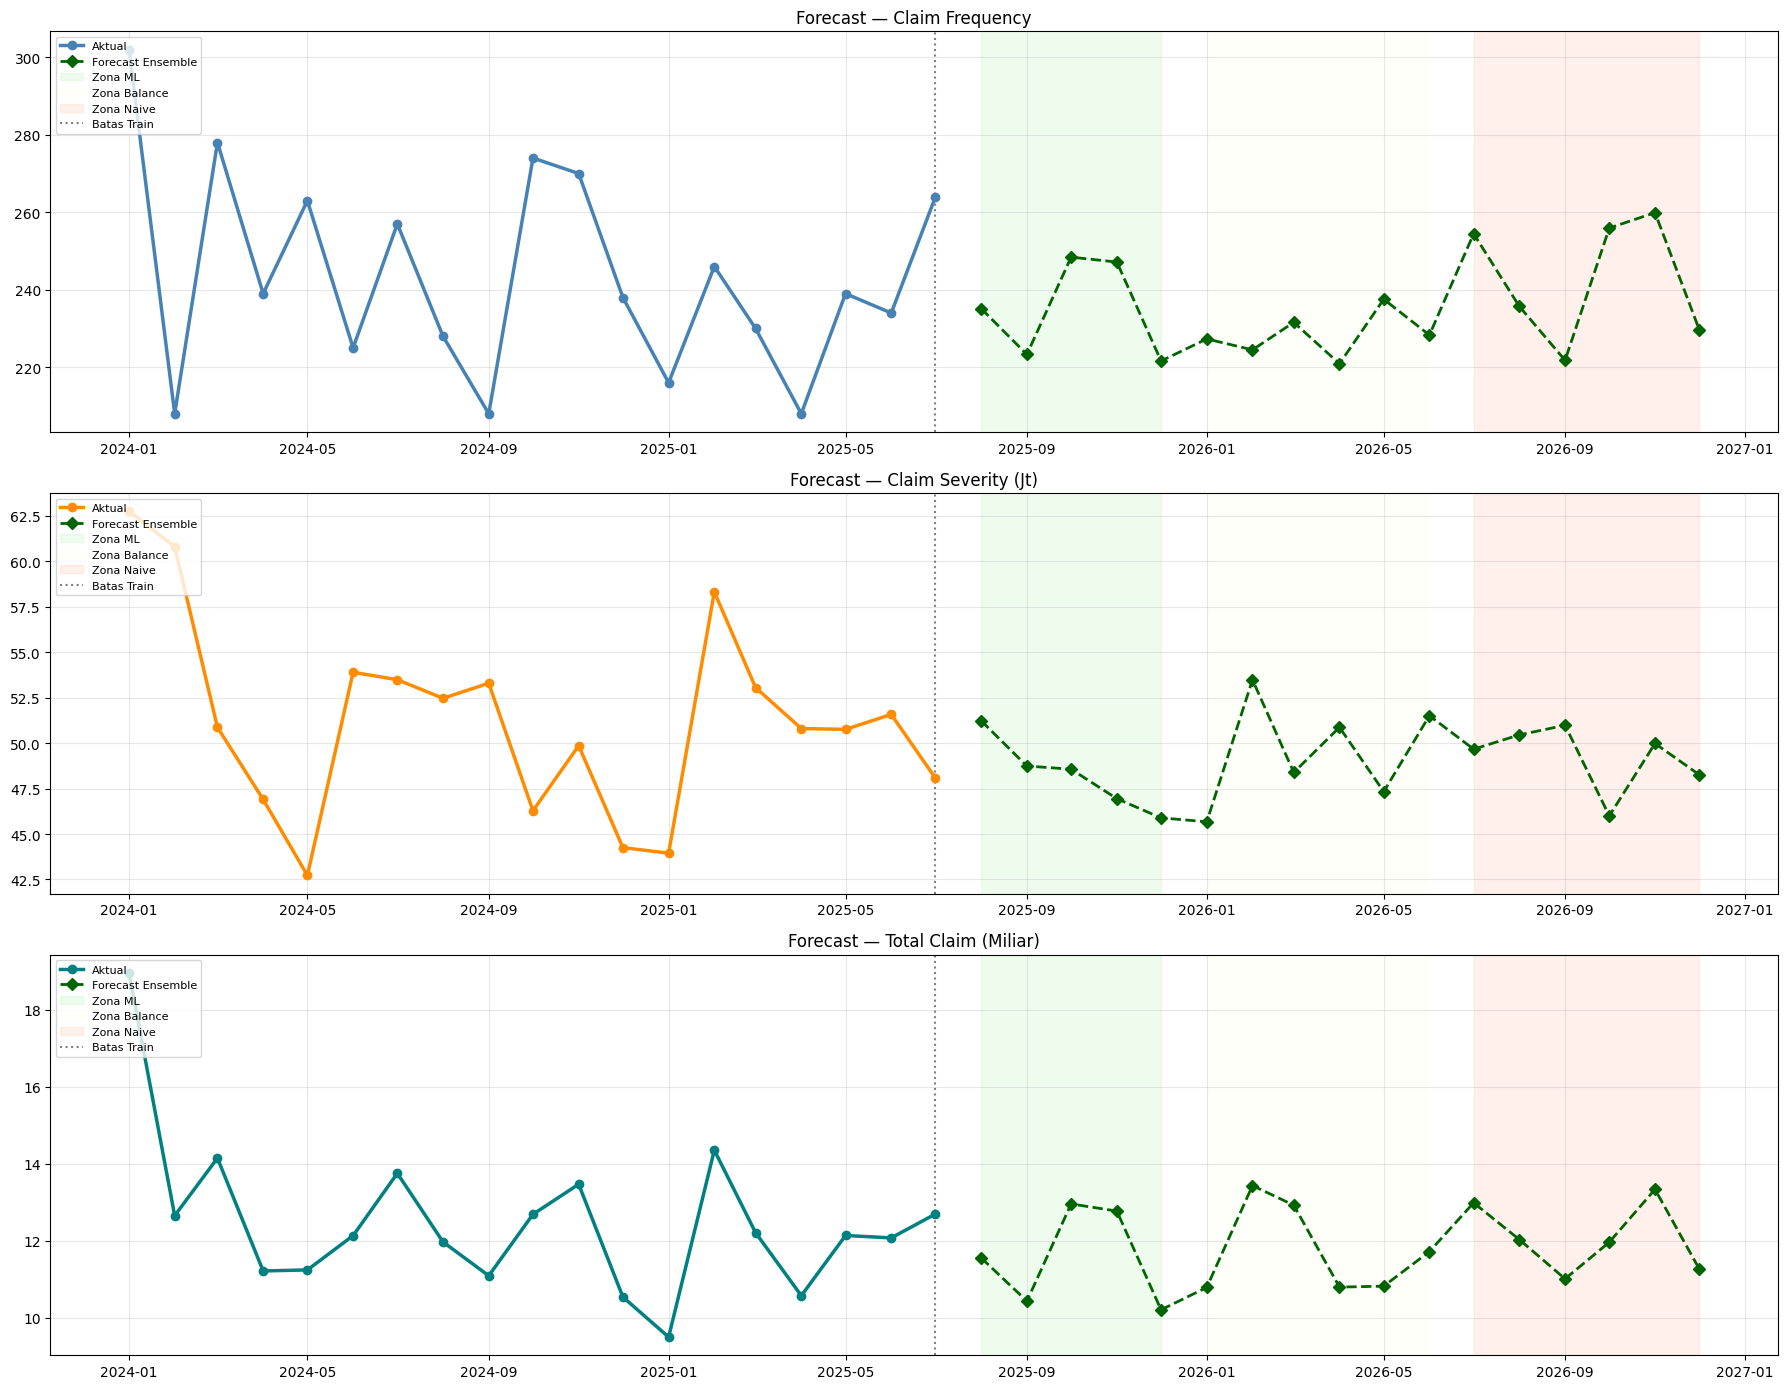


✅ Cell 6 selesai


In [6]:
# ── CELL 6: FORECAST 17 BULAN — PROGRESSIVE WEIGHTING ─

# ── PROGRESSIVE WEIGHT ZONES ───────────────────────────
# Zona 1 — Bulan 1–5   (Ags–Des 2025) : ML dominan
# Zona 2 — Bulan 6–11  (Jan–Jun 2026) : balanced
# Zona 3 — Bulan 12–17 (Jul–Des 2026) : Naive dominan
#
# Dalam tiap zona, proporsi relatif antar model
# disesuaikan dengan base_weights dari Cell 4

def get_progressive_weights(step, base_w, target_col):
    """
    step   : 0-indexed (0 = Ags 2025, 16 = Des 2026)
    base_w : dict {'prophet', 'lgbm', 'naive'} dari inverse MAPE
    
    Zone multipliers menggeser dominansi dari ML ke Naive
    seiring bertambahnya horizon.
    """
    if step <= 4:       # Zona 1: Bulan 1–5
        zone_ml    = 0.90
        zone_naive = 0.10
    elif step <= 10:    # Zona 2: Bulan 6–11
        # Interpolasi linear dari 90/10 ke 50/50
        progress   = (step - 4) / 6          # 0 → 1
        zone_ml    = 0.90 - progress * 0.40  # 90% → 50%
        zone_naive = 1 - zone_ml
    else:               # Zona 3: Bulan 12–17
        # Interpolasi linear dari 50/50 ke 20/80
        progress   = (step - 10) / 6         # 0 → 1
        zone_ml    = 0.50 - progress * 0.30  # 50% → 20%
        zone_naive = 1 - zone_ml

    # Dalam porsi ML, bagi antara Prophet & LightGBM
    # sesuai proporsi relative base_weights (exclude naive)
    total_ml_base = base_w['prophet'] + base_w['lgbm'] + 1e-9
    w_prophet = zone_ml * (base_w['prophet'] / total_ml_base)
    w_lgbm    = zone_ml * (base_w['lgbm']    / total_ml_base)
    w_naive   = zone_naive

    return round(w_prophet, 4), round(w_lgbm, 4), round(w_naive, 4)

# ── HELPER: BUILD FUTURE FEATURES ─────────────────────
def build_future_features(temp_df, next_period, next_exposure):
    """
    Bangun feature row untuk satu periode forecast.
    temp_df sudah berisi aktual + prediksi sebelumnya (recursive).
    """
    month   = next_period.month
    quarter = next_period.quarter
    t_idx   = temp_df['Time_Index'].iloc[-1] + 1

    feat = {
        'Time_Index'    : t_idx,
        'Month_Sin'     : np.sin(2 * np.pi * month / 12),
        'Month_Cos'     : np.cos(2 * np.pi * month / 12),
        'Quarter_Sin'   : np.sin(2 * np.pi * quarter / 4),
        'Quarter_Cos'   : np.cos(2 * np.pi * quarter / 4),
        'Exposure'      : next_exposure,

        # Lag Frequency
        'Freq_Lag_1'    : temp_df['Claim_Frequency'].iloc[-1],
        'Freq_Lag_2'    : temp_df['Claim_Frequency'].iloc[-2],
        'Freq_Lag_3'    : temp_df['Claim_Frequency'].iloc[-3],

        # Lag Severity
        'Sev_Lag_1'     : temp_df['Claim_Severity'].iloc[-1],
        'Sev_Lag_2'     : temp_df['Claim_Severity'].iloc[-2],
        'Sev_Lag_3'     : temp_df['Claim_Severity'].iloc[-3],

        # Lag Total
        'Total_Lag_1'   : temp_df['Total_Claim'].iloc[-1],
        'Total_Lag_2'   : temp_df['Total_Claim'].iloc[-2],

        # Rolling mean 3
        'Freq_Rolling_3'  : temp_df['Claim_Frequency'].iloc[-3:].mean(),
        'Sev_Rolling_3'   : temp_df['Claim_Severity'].iloc[-3:].mean(),
        'Total_Rolling_3' : temp_df['Total_Claim'].iloc[-3:].mean(),

        # Rolling mean 6
        'Freq_Rolling_6'  : temp_df['Claim_Frequency'].iloc[-6:].mean(),
        'Sev_Rolling_6'   : temp_df['Claim_Severity'].iloc[-6:].mean(),
        'Total_Rolling_6' : temp_df['Total_Claim'].iloc[-6:].mean(),

        # Rolling std 3
        'Freq_Std_3'    : temp_df['Claim_Frequency'].iloc[-3:].std(),
        'Sev_Std_3'     : temp_df['Claim_Severity'].iloc[-3:].std(),
    }
    return feat

# ── FORECAST LOOP 17 BULAN ─────────────────────────────
FORECAST_STEPS = 17
temp_df        = df_monthly.copy()

# Prophet forecast sekaligus 17 langkah (tidak recursive — keunggulan Prophet)
future_prophet_dates = pd.DataFrame({
    'ds': pd.date_range(start='2025-08-01', periods=FORECAST_STEPS, freq='MS')
})

prophet_freq_fc  = np.clip(
    prophet_freq.predict(future_prophet_dates)['yhat'].values, 0, None)
prophet_sev_fc   = np.clip(
    prophet_sev.predict(future_prophet_dates)['yhat'].values, 0, None)
prophet_total_fc = np.clip(
    prophet_total.predict(future_prophet_dates)['yhat'].values, 0, None)

# Hasil forecast per step
forecast_records = []

print("=" * 70)
print("FORECAST — Agustus 2025 s/d Desember 2026")
print("=" * 70)
print(f"{'Periode':<12} {'Freq':>8} {'Sev(Jt)':>10} {'Total(M)':>10} "
      f"{'wP':>6} {'wL':>6} {'wN':>6} {'Zona':>6}")
print("-" * 70)

for step in range(FORECAST_STEPS):
    next_period   = pd.Timestamp('2025-08-01') + pd.DateOffset(months=step)
    next_exposure = future_exposure[step]
    month         = next_period.month

    # ── LightGBM — recursive (pakai prediksi sebelumnya sebagai lag)
    feat   = build_future_features(temp_df, next_period, next_exposure)
    X_next = pd.DataFrame([feat])

    p_lgbm_freq  = max(0, lgbm_freq.predict(X_next[FEATURES_FREQ])[0])
    p_lgbm_sev   = max(0, lgbm_sev.predict(X_next[FEATURES_SEV])[0])
    p_lgbm_total = max(0, lgbm_total.predict(X_next[FEATURES_TOTAL])[0])

    # ── Prophet — langsung dari precomputed forecast
    p_prophet_freq  = prophet_freq_fc[step]
    p_prophet_sev   = prophet_sev_fc[step]
    p_prophet_total = prophet_total_fc[step]

    # ── Seasonal Naive
    p_naive_freq  = get_seasonal_naive(month, 'Claim_Frequency')
    p_naive_sev   = get_seasonal_naive(month, 'Claim_Severity')
    p_naive_total = get_seasonal_naive(month, 'Total_Claim')

    # ── Progressive weights per target
    wp_f, wl_f, wn_f = get_progressive_weights(step, base_weights['Claim_Frequency'], 'Claim_Frequency')
    wp_s, wl_s, wn_s = get_progressive_weights(step, base_weights['Claim_Severity'],  'Claim_Severity')
    wp_t, wl_t, wn_t = get_progressive_weights(step, base_weights['Total_Claim'],      'Total_Claim')

    # ── Ensemble
    p_freq  = wp_f * p_prophet_freq  + wl_f * p_lgbm_freq  + wn_f * p_naive_freq
    p_sev   = wp_s * p_prophet_sev   + wl_s * p_lgbm_sev   + wn_s * p_naive_sev
    p_total = wp_t * p_prophet_total + wl_t * p_lgbm_total  + wn_t * p_naive_total

    # Safety clip
    p_freq  = max(0, p_freq)
    p_sev   = max(0, p_sev)
    p_total = max(0, p_total)

    # Zona label
    zona = 'ML' if step <= 4 else ('Balance' if step <= 10 else 'Naive')

    print(f"  {next_period.strftime('%Y-%m'):<10} "
          f"{p_freq:>8.1f} {p_sev/1e6:>10.2f} {p_total/1e9:>10.3f} "
          f"{wp_f:>6.3f} {wl_f:>6.3f} {wn_f:>6.3f} {zona:>7}")

    forecast_records.append({
        'Periode_Klaim'   : next_period,
        'Claim_Frequency' : p_freq,
        'Claim_Severity'  : p_sev,
        'Total_Claim'     : p_total,
        'w_Prophet'       : wp_f,
        'w_LightGBM'      : wl_f,
        'w_Naive'         : wn_f,
        'Zona'            : zona,
    })

    # Update temp_df untuk recursive LightGBM step berikutnya
    new_row = pd.DataFrame([{
        'Periode_Klaim'   : next_period,
        'Claim_Frequency' : p_freq,
        'Claim_Severity'  : p_sev,
        'Total_Claim'     : p_total,
        'Time_Index'      : temp_df['Time_Index'].iloc[-1] + 1,
        'Exposure'        : next_exposure,
        'Month'           : month,
        'Quarter'         : next_period.quarter,
    }])
    temp_df = pd.concat([temp_df, new_row], ignore_index=True)

df_forecast = pd.DataFrame(forecast_records)

# ── VISUALISASI FORECAST ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

configs = [
    ('Claim_Frequency', 'Claim Frequency',      'steelblue',  1),
    ('Claim_Severity',  'Claim Severity (Jt)',  'darkorange', 1e6),
    ('Total_Claim',     'Total Claim (Miliar)', 'teal',       1e9),
]

zone_colors = {'ML': 'lightgreen', 'Balance': 'lightyellow', 'Naive': 'lightsalmon'}

for ax, (col, label, color, divisor) in zip(axes, configs):
    # Aktual
    ax.plot(
        df_monthly['Periode_Klaim'],
        df_monthly[col] / divisor,
        marker='o', color=color, linewidth=2.5, label='Aktual', zorder=3
    )
    # Forecast
    ax.plot(
        df_forecast['Periode_Klaim'],
        df_forecast[col] / divisor,
        marker='D', color='darkgreen', linewidth=2,
        linestyle='--', label='Forecast Ensemble', zorder=3
    )
    # Shade zona
    for zona, zcolor in zone_colors.items():
        zona_df = df_forecast[df_forecast['Zona'] == zona]
        if len(zona_df) > 0:
            ax.axvspan(
                zona_df['Periode_Klaim'].min(),
                zona_df['Periode_Klaim'].max(),
                alpha=0.15, color=zcolor, label=f'Zona {zona}'
            )
    # Garis batas train
    ax.axvline(x=pd.Timestamp('2025-07-01'),
               color='gray', linestyle=':', linewidth=1.5, label='Batas Train')
    ax.set_title(f'Forecast — {label}')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Cell 6 selesai")

In [7]:
# ── CELL 7: SUBMISSION KAGGLE & EVALUASI FINAL ─────────

# ── READ SAMPLE SUBMISSION ─────────────────────────────
submission = pd.read_csv('sample_submission.csv')
print("=" * 50)
print("SAMPLE SUBMISSION FORMAT")
print("=" * 50)
print("Kolom:", submission.columns.tolist())
display(submission.head(10))
print(f"Total rows sample: {len(submission)}")

# ── FILL SUBMISSION DARI FORECAST ─────────────────────
for _, row in df_forecast.iterrows():
    month_str = row['Periode_Klaim'].strftime('%Y_%m')

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Frequency", 'value'
    ] = row['Claim_Frequency']

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Severity", 'value'
    ] = row['Claim_Severity']

    submission.loc[
        submission['id'] == f"{month_str}_Total_Claim", 'value'
    ] = row['Total_Claim']

# ── QUALITY CHECK ──────────────────────────────────────
print("\n" + "=" * 50)
print("QUALITY CHECK SUBMISSION")
print("=" * 50)
print(f"  Total rows     : {len(submission)}")
print(f"  Nilai negatif  : {(submission['value'] < 0).sum()}")
print(f"  Nilai NaN      : {submission['value'].isna().sum()}")
print(f"  Nilai nol      : {(submission['value'] == 0).sum()}")

assert submission['value'].isna().sum() == 0, "❌ Ada NaN di submission!"
assert (submission['value'] >= 0).all(),      "❌ Ada nilai negatif di submission!"
print("  ✅ Validasi passed")

submission.to_csv('submission_prophet_early.csv', index=False)
print("\n✅ submission_prophet_early.csv tersimpan")
display(submission)

SAMPLE SUBMISSION FORMAT
Kolom: ['id', 'value']


,id,value
0,2025_08_Claim_Frequency,0
1,2025_08_Claim_Severity,0
2,2025_08_Total_Claim,0
3,2025_09_Claim_Frequency,0
4,2025_09_Claim_Severity,0
5,2025_09_Total_Claim,0
6,2025_10_Claim_Frequency,0
7,2025_10_Claim_Severity,0
8,2025_10_Total_Claim,0
9,2025_11_Claim_Frequency,0


Total rows sample: 15

QUALITY CHECK SUBMISSION
  Total rows     : 15
  Nilai negatif  : 0
  Nilai NaN      : 0
  Nilai nol      : 0
  ✅ Validasi passed

✅ submission_prophet_early.csv tersimpan


,id,value
0,2025_08_Claim_Frequency,2.351437e+02
1,2025_08_Claim_Severity,5.122600e+07
2,2025_08_Total_Claim,1.154902e+10
3,2025_09_Claim_Frequency,2.232985e+02
4,2025_09_Claim_Severity,4.874072e+07
5,2025_09_Total_Claim,1.042609e+10
6,2025_10_Claim_Frequency,2.484166e+02
7,2025_10_Claim_Severity,4.856402e+07
8,2025_10_Total_Claim,1.295066e+10
9,2025_11_Claim_Frequency,2.471491e+02
